##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise 

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class** 

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold 
  - The model only detects objects from the **COCO dataset (80 classes)**  


In [70]:
# Import Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load the pretrained Mask R-CNN model
import tensorflow_hub as hub

detector = hub.load("https://kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2/frameworks/TensorFlow2/variations/1024x1024/versions/1")



In [72]:
coco_classes = {
    1: "person", 2: "bicycle", 3: "car", 4: "motorcycle", 5: "airplane",
    6: "bus", 7: "train", 8: "truck", 9: "boat", 10: "traffic light",
    11: "fire hydrant", 13: "stop sign", 14: "parking meter", 15: "bench",
    16: "bird", 17: "cat", 18: "dog", 19: "horse", 20: "sheep",
    21: "cow", 22: "elephant", 23: "bear", 24: "zebra", 25: "giraffe",
    27: "backpack", 28: "umbrella", 31: "handbag", 32: "tie", 33: "suitcase",
    34: "frisbee", 35: "skis", 36: "snowboard", 37: "sports ball",
    38: "kite", 39: "baseball bat", 40: "baseball glove", 41: "skateboard",
    42: "surfboard", 43: "tennis racket", 44: "bottle", 46: "wine glass",
    47: "cup", 48: "fork", 49: "knife", 50: "spoon", 51: "bowl",
    52: "banana", 53: "apple", 54: "sandwich", 55: "orange", 56: "broccoli",
    57: "carrot", 58: "hot dog", 59: "pizza", 60: "donut", 61: "cake",
    62: "chair", 63: "couch", 64: "potted plant", 65: "bed", 67: "dining table",
    70: "toilet", 72: "tv", 73: "laptop", 74: "mouse", 75: "remote",
    76: "keyboard", 77: "cell phone", 78: "microwave", 79: "oven",
    80: "toaster", 81: "sink", 82: "refrigerator", 84: "book", 85: "clock",
    86: "vase", 87: "scissors", 88: "teddy bear", 89: "hair drier",
    90: "toothbrush"
}

In [ ]:
# Perform inference using the model
def inference(img):
    # read image file
    img = tf.io.read_file(img)
    
    # decode image to tensor
    img = tf.image.decode_jpeg(img, channels=3)
    
    # add batch dimension
    image_tensor = tf.expand_dims(img, axis=0)   # shape becomes (1, h, w, 3)
    
    # run detector
    detector_output = detector(image_tensor)
    
    # get class ids
    class_ids = detector_output["detection_classes"]
    boxes = detector_output["detection_boxes"]
    scores = detector_output["detection_scores"]
    masks = detector_output["detection_masks"]
    
    return img, class_ids, boxes, scores, masks

In [ ]:
# Select and load 5 different images 
images = ["airplane.jpg", "laptop.jpg", "pizza.jpg", "teddy bear.jpg", "tennis racket.jpg"]


# Extract prediction outputs
for img_path in images:
    img, class_ids, boxes, scores, masks = inference(img_path)
    print("Image:", img_path)
    print("Boxes shape:", boxes.shape)
    print("Scores shape:", scores.shape)
    print("Masks shape:", masks.shape)
    print("Class IDs:", class_ids[0][:5])   
    print("-" * 40)

Image: airplane.jpg
Boxes shape: (1, 100, 4)
Scores shape: (1, 100)
Masks shape: (1, 100, 33, 33)
Class IDs: tf.Tensor([5. 5. 3. 1. 5.], shape=(5,), dtype=float32)
----------------------------------------
Image: laptop.jpg
Boxes shape: (1, 100, 4)
Scores shape: (1, 100)
Masks shape: (1, 100, 33, 33)
Class IDs: tf.Tensor([73. 73. 76. 62. 72.], shape=(5,), dtype=float32)
----------------------------------------
Image: pizza.jpg
Boxes shape: (1, 100, 4)
Scores shape: (1, 100)
Masks shape: (1, 100, 33, 33)
Class IDs: tf.Tensor([59. 48. 50.  1. 79.], shape=(5,), dtype=float32)
----------------------------------------
Image: teddy bear.jpg
Boxes shape: (1, 100, 4)
Scores shape: (1, 100)
Masks shape: (1, 100, 33, 33)
Class IDs: tf.Tensor([ 1. 62. 88. 63. 62.], shape=(5,), dtype=float32)
----------------------------------------
Image: tennis racket.jpg
Boxes shape: (1, 100, 4)
Scores shape: (1, 100)
Masks shape: (1, 100, 33, 33)
Class IDs: tf.Tensor([ 1.  1. 37.  1. 37.], shape=(5,), dtype=flo

In [ ]:
# Visualize the results

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tensorflow as tf

def visualize_predictions(img, class_ids, boxes, scores, masks, threshold=0.5, mask_threshold=0.5):
    img_np = img.numpy().astype(np.uint8).copy()
    h, w, _ = img_np.shape

    fig, ax = plt.subplots(1, figsize=(12, 8))

    class_ids = class_ids[0].numpy().astype(int)
    boxes = boxes[0].numpy()
    scores = scores[0].numpy()
    masks = masks[0].numpy()

    for i in range(len(scores)):
        if scores[i] < threshold:
            continue

        y1, x1, y2, x2 = boxes[i]

        x1 = int(x1 * w)
        x2 = int(x2 * w)
        y1 = int(y1 * h)
        y2 = int(y2 * h)

        # Skip invalid bounding boxes
        if x2 <= x1 or y2 <= y1:
            continue

        # Get class label
        label = coco_classes.get(class_ids[i], "N/A")

        # Original mask for this object
        mask = masks[i]

        # Resize mask to match bounding box size
        mask = tf.image.resize(mask[..., np.newaxis], (y2 - y1, x2 - x1))
        mask = tf.squeeze(mask).numpy()

        # Convert to binary mask
        mask = mask > mask_threshold

        # Extract region inside bounding box
        region = img_np[y1:y2, x1:x2].copy()

        # Random color for mask visualization
        color = np.random.randint(0, 256, size=3, dtype=np.uint8)

        # Apply color only on masked pixels
        region[mask] = (0.7 * region[mask] + 0.3 * color).astype(np.uint8)

        img_np[y1:y2, x1:x2] = region

        # Draw bounding box
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)

        # Display label and confidence score
        ax.text(
            x1, max(y1 - 5, 5),
            f"{label}: {scores[i]:.2f}",
            color='white',
            fontsize=10,
            bbox=dict(facecolor='red', alpha=0.6)
        )

    ax.imshow(img_np)
    ax.axis("off")
    plt.show()

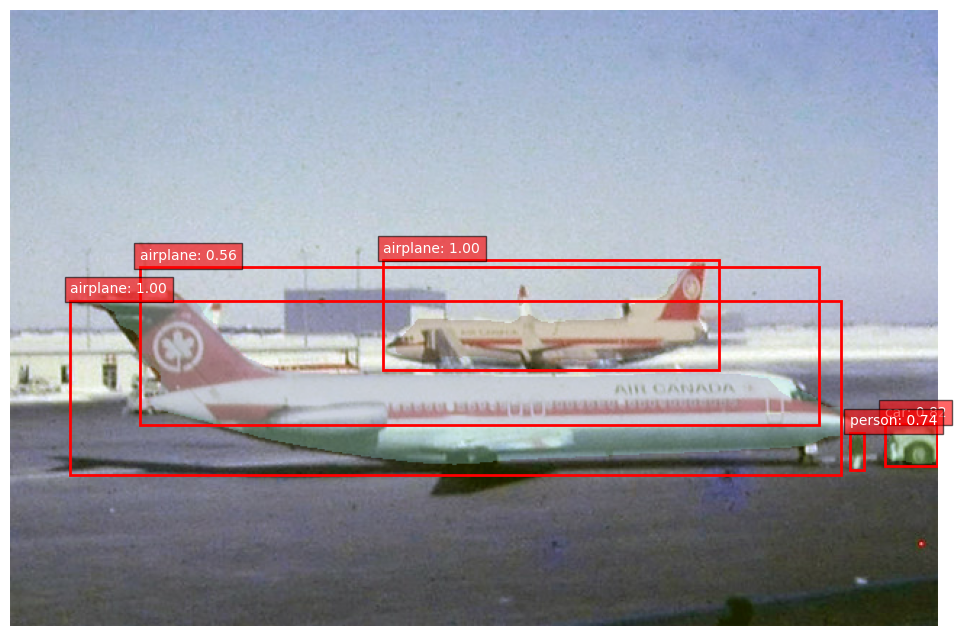

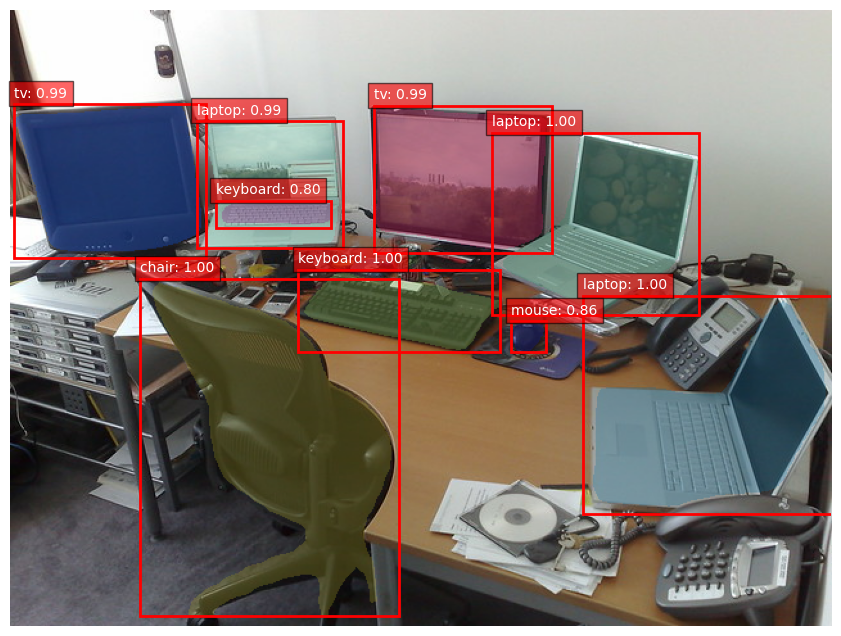

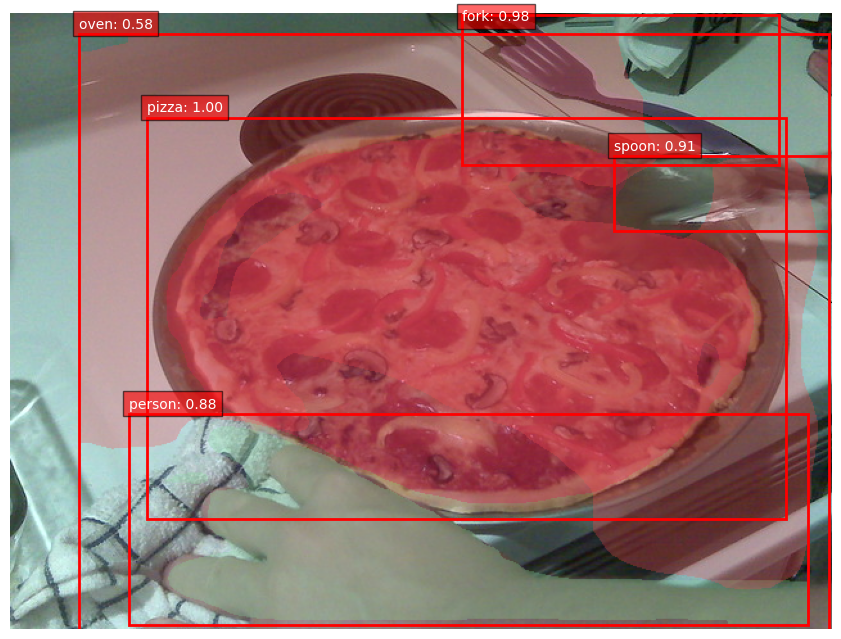

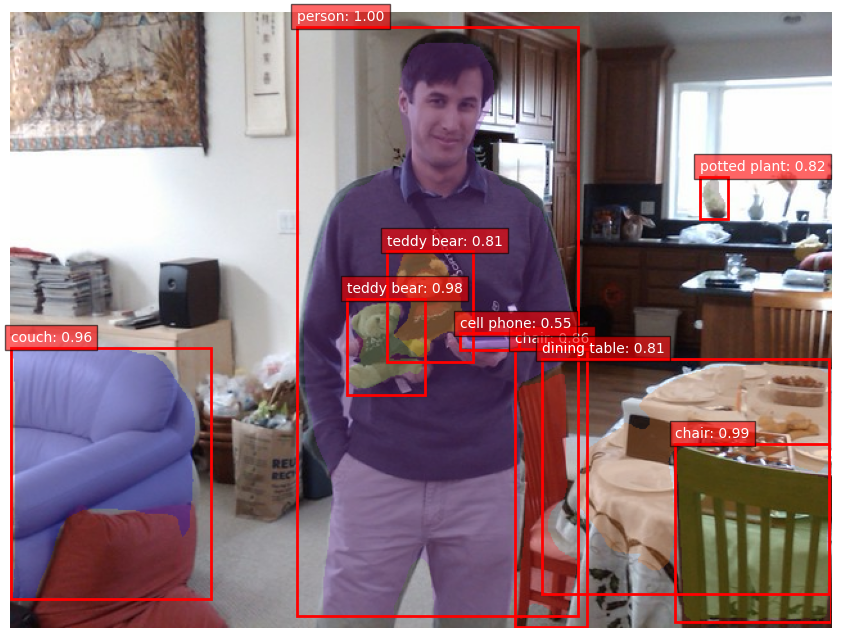

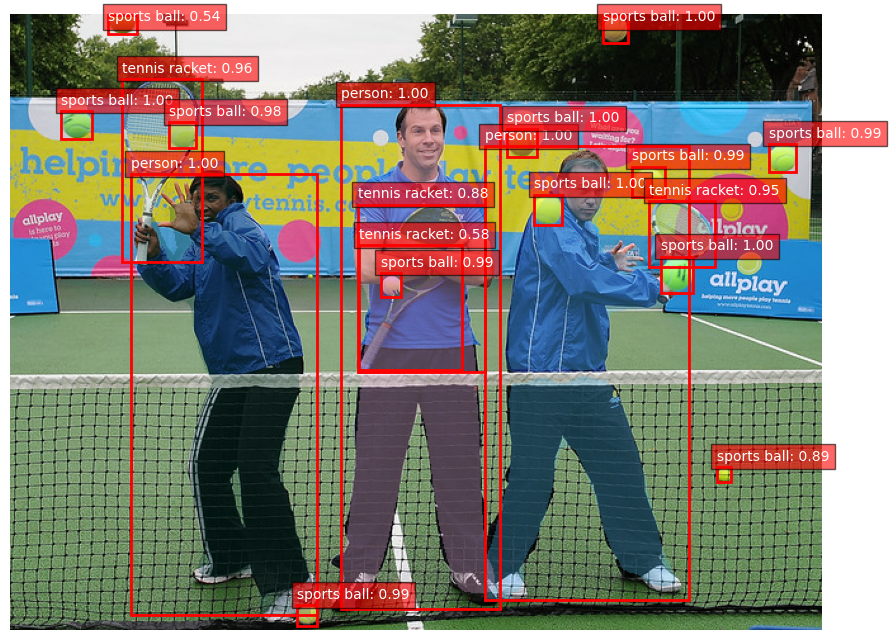

In [ ]:
# Experiment with 0.5 confidence thresholds

for img_path in images:
    img, class_ids, boxes, scores, masks = inference(img_path)

    visualize_predictions(img, class_ids, boxes, scores, masks, threshold=0.5)

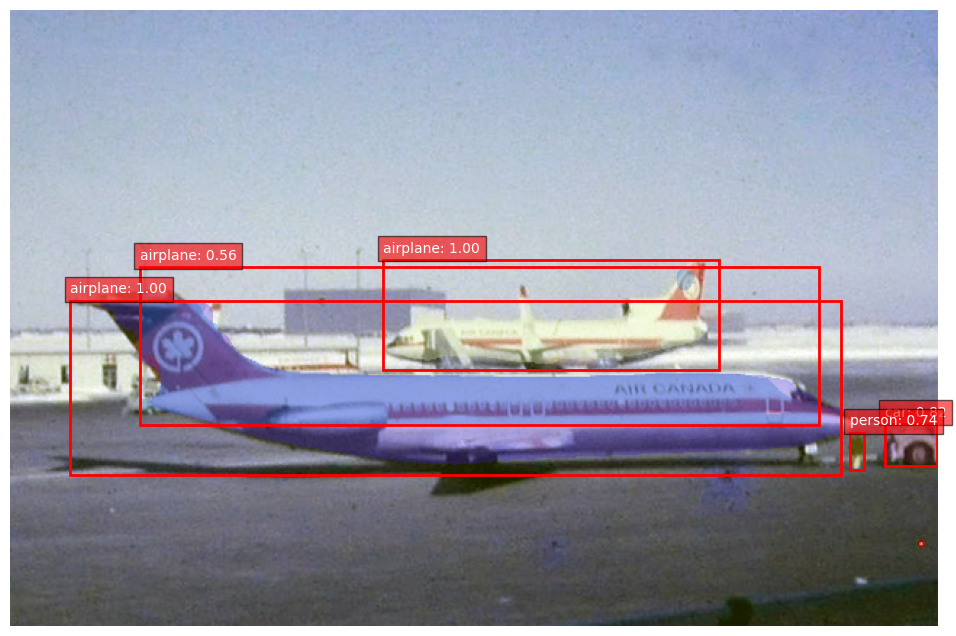

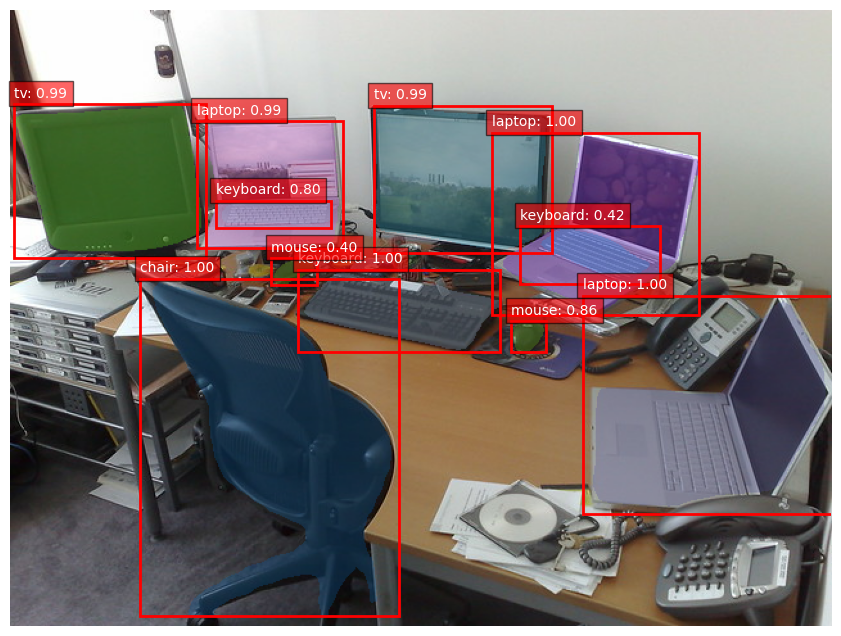

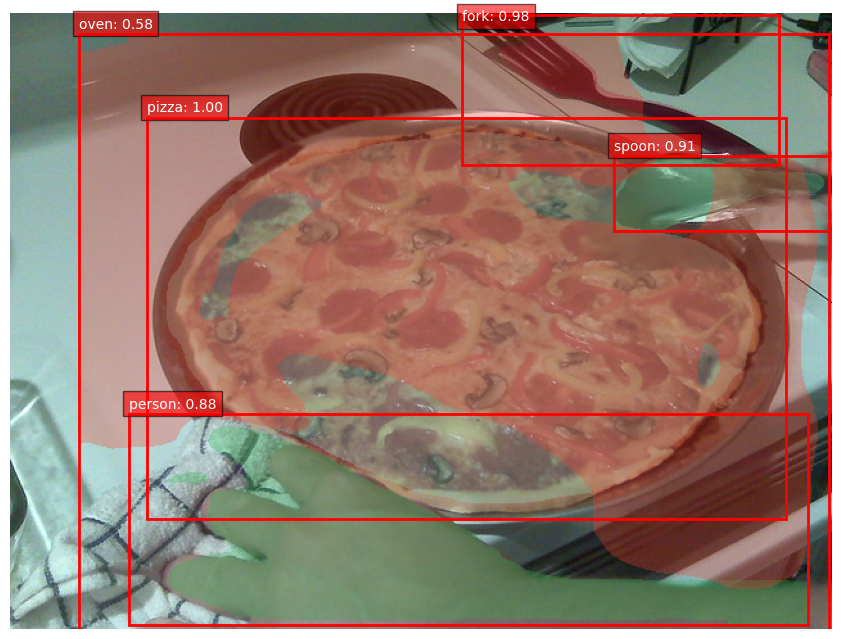

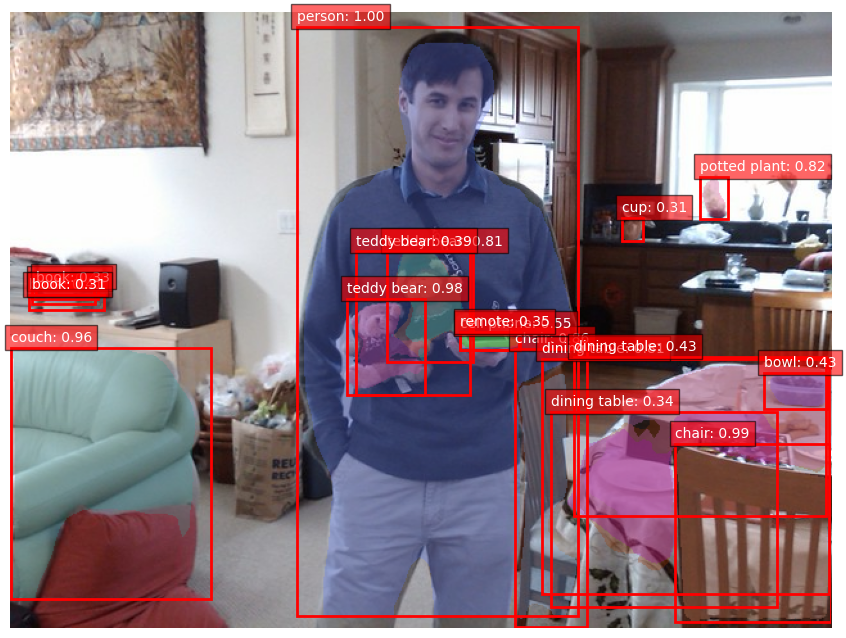

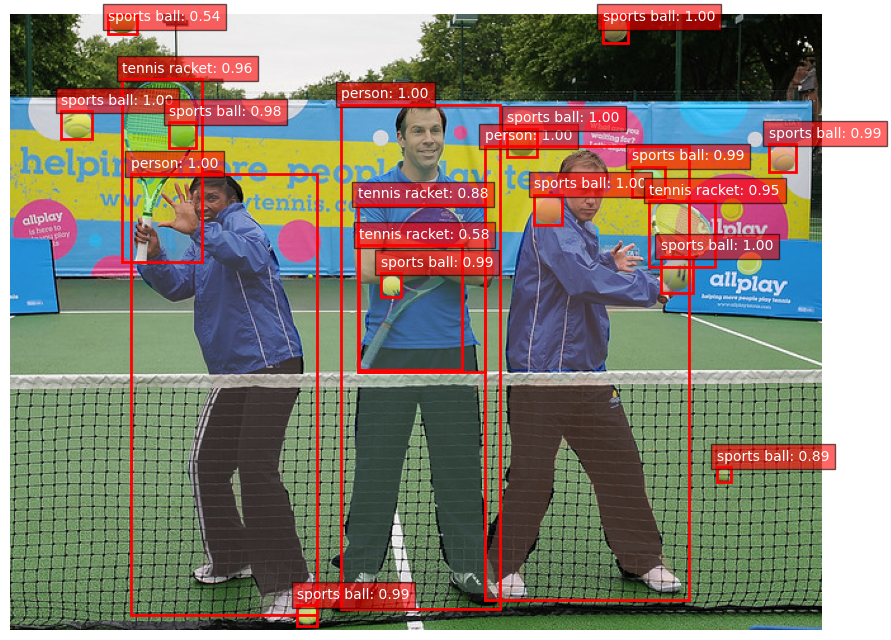

In [ ]:
# Experiment with 0.3 confidence thresholds

for img_path in images:
    img, class_ids, boxes, scores, masks = inference(img_path)

    visualize_predictions(img, class_ids, boxes, scores, masks, threshold=0.3)